All descriptors     : 37
Selected descriptors: 21

All descriptor names:
01. RMS
02. Standard_Deviation
03. Mean
04. Median
05. Mode
06. Max_Amplitude
07. Min_Amplitude
08. Amplitude_Scale
09. Amplitude_Ratio
10. Unique_Value
11. Number_Glitch
12. Glitch_Duration
13. Spikes
14. Slope
15. Intercept
16. L4min
17. L4max
18. d4
19. H4min
20. H4max
21. L19min
22. L19max
23. d19
24. H19min
25. H19max
26. L100min
27. L100max
28. d100
29. H100min
30. H100max
31. L325min
32. L325max
33. d325
34. H325min
35. H325max
36. Dominant_Frequency
37. Dominant_Power

Selected descriptor names:
01. RMS
02. Mean
03. Amplitude_Ratio
04. Unique_Value
05. Number_Glitch
06. Glitch_Duration
07. Spikes
08. Slope
09. L4min
10. d4
11. H4max
12. L19min
13. d19
14. H19max
15. L100min
16. d100
17. H100max
18. L325min
19. d325
20. H325max
21. Dominant_Frequency

Signal characteristic class names:
00. BS
01. BT
02. CP
03. HCA
04. IN
05. IS
06. LFN
07. LOS
08. Normal
09. RD
10. STO
11. SWO
12. UIR
Training samples: 6648

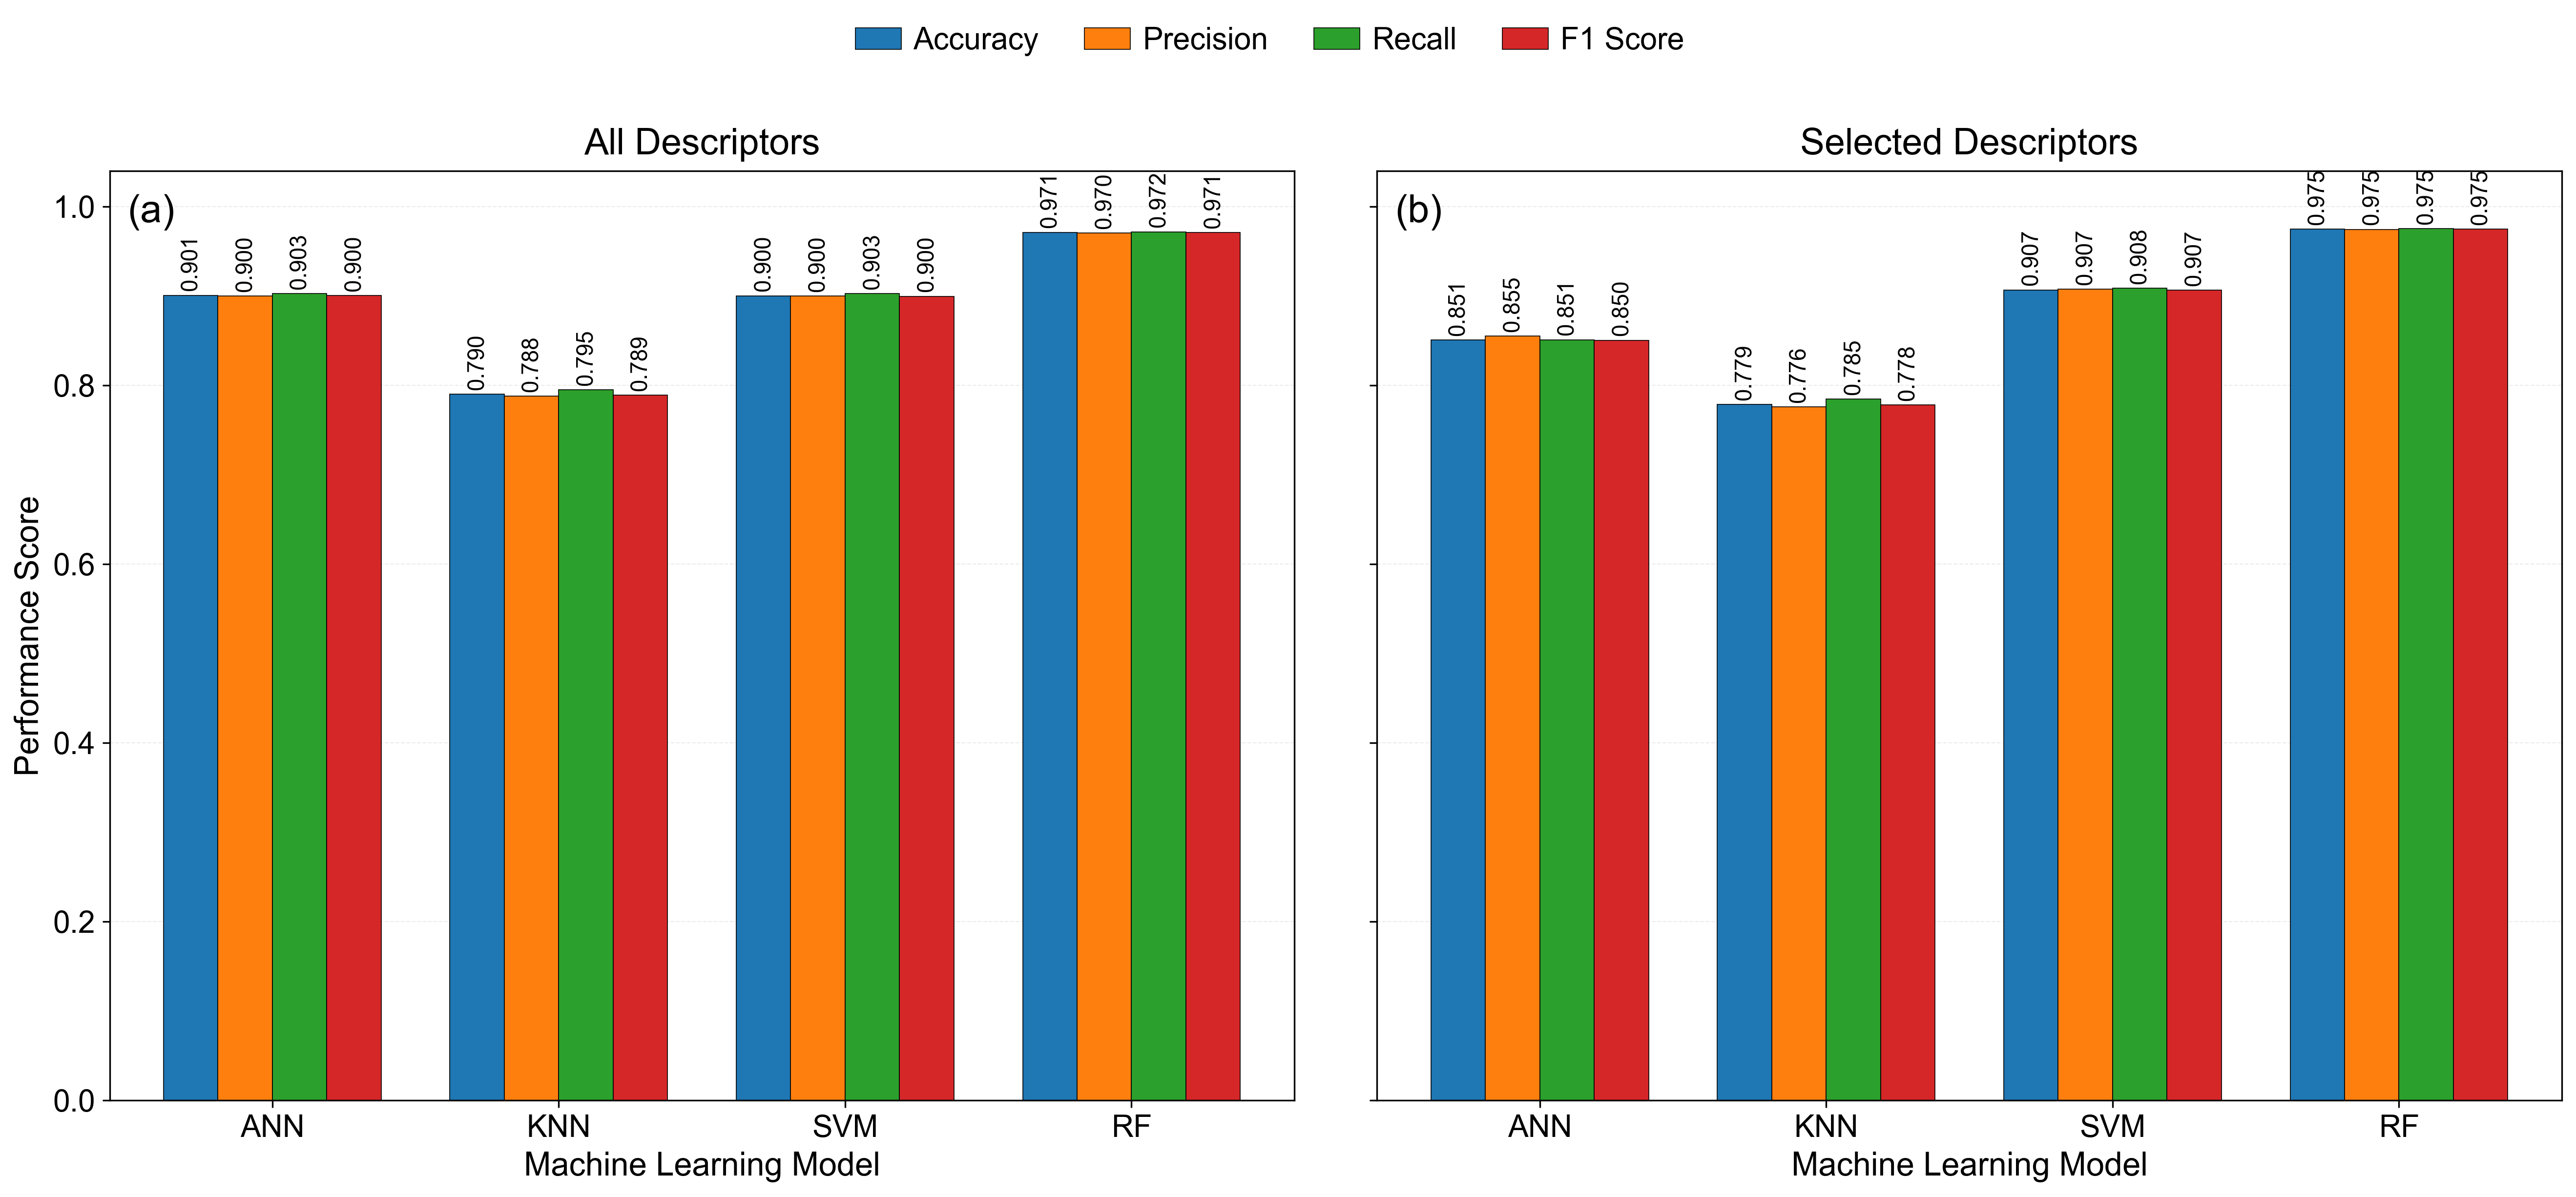

In [7]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.neural_network import MLPClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,classification_report)
warnings.filterwarnings("ignore")

# ============================================================
# 1. RANDOM STATE
# ============================================================
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ============================================================
# 2. GLOBAL PLOT STYLE
# ============================================================
FS_TITLE  = 18
FS_LABEL  = 16
FS_TICK   = 15
FS_LEGEND = 15
FS_VALUE  = 11
DISPLAY_DPI = 300
SAVE_DPI    = 600

plt.rcParams.update({
    "font.family": "Arial", "font.size": FS_TICK,
    "axes.titlesize": FS_TITLE, "axes.labelsize": FS_LABEL,
    "xtick.labelsize": FS_TICK, "ytick.labelsize": FS_TICK,
    "legend.fontsize": FS_LEGEND, "axes.linewidth": 0.8})

# ============================================================
# 3. PATH
# ============================================================
pathNow = os.path.abspath(os.path.join(os.path.abspath(""),"../"))
excel_path = os.path.join(pathNow,"Dataset","Dataset.xlsx")

# ============================================================
# 4. LOAD TWO DATASETS
# ============================================================
df_all = pd.read_excel(excel_path,sheet_name="AllDescriptors")
df_selected = pd.read_excel(excel_path,sheet_name="SelectedDescriptors")

# ============================================================
# 5. TARGET AND NON-FEATURE COLUMNS
# ============================================================
TARGET = "Signal_Characteristic"
metadata_cols = ["DataNumber","StationID","Channel","Location","Starttime","Endtime"]

# ============================================================
# 6. PREPROCESSING FUNCTION
# ============================================================
def prepare_dataset(df):
    df = df.copy()

    if TARGET not in df.columns:
        raise ValueError(f"Target '{TARGET}' tidak ditemukan.")
    df = df.dropna(subset=[TARGET]).reset_index(drop=True)
    y_raw = (df[TARGET].astype(str).copy())

    drop_cols = ([TARGET]+ metadata_cols)
    drop_cols = [c for c in drop_cols if c in df.columns]
    X = df.drop(columns=drop_cols, errors="ignore").copy()

    for col in X.columns:
        X[col] = pd.to_numeric(X[col], errors="coerce")

    X = X.replace([np.inf, -np.inf],np.nan)
    all_nan_cols = [col for col in X.columns if X[col].notna().sum() == 0]

    if all_nan_cols: print("\nRemoved all-NaN columns:")
    for col in all_nan_cols:print(" -", col)
    X = X.drop(columns=all_nan_cols)
    X = X.fillna(X.median())
    return X, y_raw

# ============================================================
# 7. PREPARE BOTH DATASETS
# ============================================================
X_all, y_all_raw = prepare_dataset(df_all)
X_selected, y_selected_raw = prepare_dataset(df_selected)

# ============================================================
# 8. CHECK DATA CONSISTENCY
# ============================================================
if len(y_all_raw) != len(y_selected_raw):
    raise ValueError(
        "Jumlah sampel pada AllDescriptors "
        "dan SelectedDescriptors berbeda.")
if not np.array_equal(y_all_raw.to_numpy(), y_selected_raw.to_numpy()):
    raise ValueError(
        "Urutan Signal_Characteristic pada "
        "AllDescriptors dan SelectedDescriptors "
        "tidak identik.")

print("All descriptors     :", X_all.shape[1])
print("Selected descriptors:", X_selected.shape[1])
print("\nAll descriptor names:")
for i, f in enumerate(X_all.columns, start=1):
    print(f"{i:02d}. {f}")

print("\nSelected descriptor names:")
for i, f in enumerate(X_selected.columns, start=1):
    print(f"{i:02d}. {f}")

# ============================================================
# 9. ENCODE TARGET ONCE
# ============================================================
target_encoder = LabelEncoder()
y = target_encoder.fit_transform(y_all_raw)
class_names = target_encoder.classes_

print("\nSignal characteristic class names:")
for i, cls in enumerate(class_names):
    print(f"{i:02d}. {cls}")

# ============================================================
# 10. IDENTICAL TRAIN / TEST SPLIT
# ============================================================
indices = np.arange(len(y))
train_idx, test_idx = train_test_split(indices,test_size=0.20,random_state=RANDOM_STATE,shuffle=True,stratify=y)
y_train = y[train_idx]
y_test = y[test_idx]
print("Training samples:",len(train_idx))
print("Testing samples :",len(test_idx))

# ============================================================
# 11. MODEL 
# ============================================================
def create_models():
    return {
        # ----------------------------------------------------
        # ANN
        # ----------------------------------------------------
        "ANN": MLPClassifier(
            hidden_layer_sizes=(128, 64),
            activation="relu",
            solver="adam",
            alpha=1e-4,
            learning_rate="adaptive",
            max_iter=500,
            early_stopping=True,
            random_state=RANDOM_STATE),

        # ----------------------------------------------------
        # KNN
        # ----------------------------------------------------
        "KNN": KNeighborsClassifier(
            n_neighbors=5,
            weights="distance",
            p=2,
            n_jobs=-1),

        # ----------------------------------------------------
        # SVM
        # ----------------------------------------------------
        "SVM": SVC(
            kernel="rbf",
            C=200.0,
            gamma="scale",
            random_state=RANDOM_STATE),

        # ----------------------------------------------------
        # RANDOM FOREST
        # ----------------------------------------------------
        "RF": RandomForestClassifier(
            n_estimators=800,
            max_depth=None,
            max_features="sqrt",
            min_samples_split=2,
            min_samples_leaf=1,
            bootstrap=True,
            random_state=RANDOM_STATE,
            n_jobs=-1)}

# ============================================================
# 12. EVALUATION FUNCTION
# ============================================================
def evaluate_feature_set(X,feature_set_name):
    X_train = X.iloc[train_idx].copy()
    X_test = X.iloc[test_idx].copy()

    # --------------------------------------------------------
    # Scaling
    # ANN, KNN, SVM use standardized features
    # RF uses original features
    # --------------------------------------------------------
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_test_scaled = scaler.transform(X_test)
    models = create_models()
    results = []
    print("\n")
    print("=" * 75)
    print(feature_set_name.upper())
    print("=" * 75)

    for model_name, model in models.items():
        print("\n" + "-" * 65)
        print(f"{feature_set_name} | {model_name}")
        print("-" * 65)

        if model_name in ["ANN","KNN","SVM"]:
            Xtr = X_train_scaled
            Xte = X_test_scaled
        else:
            Xtr = X_train.values
            Xte = X_test.values

        model.fit(Xtr,y_train)
        y_pred = model.predict(Xte)
        accuracy = accuracy_score(y_test,y_pred)
        precision = precision_score(y_test,y_pred,average="macro",zero_division=0)

        recall = recall_score(y_test,y_pred,average="macro",zero_division=0)
        f1 = f1_score(y_test,y_pred,average="macro",zero_division=0)
        results.append({
            "Feature Set":feature_set_name,
            "Model":model_name,
            "Accuracy":accuracy,
            "Precision":precision,
            "Recall":recall,
            "F1 Score":f1})

        print(f"Accuracy  : {accuracy:.4f}")
        print(f"Precision : {precision:.4f}")
        print(f"Recall    : {recall:.4f}")
        print(f"F1 Score  : {f1:.4f}")
        print("\nClassification Report:\n")
        print(classification_report(y_test,y_pred, labels=np.arange(len(class_names)),target_names=class_names,digits=4,zero_division=0))
    return pd.DataFrame(results)

results_all = evaluate_feature_set(X_all,"All Descriptors")
results_selected = evaluate_feature_set(X_selected,"Selected Descriptors")
results_combined = pd.concat([results_all, results_selected],ignore_index=True)
print("\n")
print("=" * 85)
print("FINAL PERFORMANCE COMPARISON")
print("=" * 85)
print(results_combined.round(4).to_string(index=False))

# ============================================================
# 13. PERFORMANCE CHANGE
# ============================================================
metrics = ["Accuracy", "Precision", "Recall", "F1 Score"]
all_indexed = (results_all.set_index("Model"))
selected_indexed = (results_selected.set_index("Model"))
change_df = pd.DataFrame(index=all_indexed.index)

for metric in metrics:
    change_df[f"{metric}_All"] = all_indexed[metric]
    change_df[f"{metric}_Selected"] = selected_indexed[metric]
    change_df[f"{metric}_Change"] = (selected_indexed[metric]-all_indexed[metric])

# ============================================================
# 14. PLOT DATA
# ============================================================
model_order = ["ANN","KNN","SVM","RF"]
all_plot = (results_all.set_index("Model").loc[model_order,metrics])
selected_plot = (results_selected.set_index("Model").loc[model_order,metrics])

fig, axes = plt.subplots(1,2, figsize=(18, 9 ),sharey=True)

x = np.arange(len(model_order))
bar_width = 0.19
offsets = np.array([-1.5,-0.5, 0.5, 1.5]) * bar_width

def draw_panel(ax,data,title,panel_label):
    for i, metric in enumerate(metrics):
        bars = ax.bar(x + offsets[i],
            data[metric].values,
            width=bar_width,
            label=metric,
            edgecolor="black",
            linewidth=0.4)

        ax.bar_label( bars,fmt="%.3f",fontsize=FS_VALUE, padding=2,rotation=90)

    ax.set_xticks( x )
    ax.set_xticklabels( model_order, rotation=0)
    ax.set_xlabel("Machine Learning Model",fontsize=FS_LABEL)
    ax.set_ylim( 0,1.04)
    ax.set_yticks( np.arange(0,1.01,0.2 ))

    ax.grid( axis="y", linestyle="--", linewidth=0.5, alpha=0.25)
    ax.grid(axis="x",visible=False)
    ax.set_axisbelow(True)

    ax.set_title( title, fontsize=FS_TITLE, pad=8)
    ax.text(0.015,0.975,panel_label,transform=ax.transAxes,ha="left", va="top",fontsize=FS_TITLE + 1)

draw_panel(axes[0], all_plot,"All Descriptors","(a)")
axes[0].set_ylabel("Performance Score",fontsize=FS_LABEL)

draw_panel(axes[1],selected_plot,"Selected Descriptors","(b)")

handles, labels = (axes[0].get_legend_handles_labels())
fig.legend(handles,labels,loc="upper center",bbox_to_anchor=( 0.5, 0.985),
    ncol=4,frameon=False,fontsize=FS_LEGEND,handlelength=1.5,handletextpad=0.4,columnspacing=1.5)

fig.subplots_adjust(left=0.060, right=0.990,bottom=0.15,top=0.855,wspace=0.07)

plt.show()